# Decoding method comparison

Compares available model-31 decoding variants across two axes:

**Part 1 – noise model × voxel selection** (n=39 subjects, model31.smoothed):
- Noise: full covariance vs. spherical (isotropic)
- Voxels: top-100 by training R² vs. all CV-R²>0 (nvoxels=0)
- Target: true numerosity (no `--fit_responses`)

**Part 2 – lambda sweep** (fit_responses, nvoxels=200):
- Lambda blends parametric covariance (0) with empirical sample covariance (1)
- Values: 0.1 – 1.0, 39 subjects each

Primary metric: Pearson r (decoded posterior mean E vs. true target x), averaged per subject then compared across conditions.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from neural_priors.utils.data import get_all_subject_ids

bids_folder = Path('/data/ds-neuralpriors')
subjects = get_all_subject_ids()
print(f'{len(subjects)} subjects: {subjects[:5]} ... {subjects[-5:]}')

39 subjects: ['01', '02', '03', '04', '05'] ... ['37', '38', '39', '40', '41']


In [2]:
# ── helpers ──────────────────────────────────────────────────────────────────

def build_key(model_label=31, smoothed=True, spherical_noise=False,
               fit_responses=False, separate_sigmas=False,
               subtract_wt_baseline=False, lambd=0.0):
    """Reconstruct the directory key that decode.py uses."""
    key = f'model{model_label}'
    if smoothed:             key += '.smoothed'
    if spherical_noise:      key += '.spherical_noise'
    if fit_responses:        key += '.fit_responses'
    if separate_sigmas:      key += '.separate_sigmas'
    if subtract_wt_baseline: key += '.subtract_wt_baseline'
    if lambd > 0.0:          key += f'.lambd-{lambd}'
    return key


def load_pdf(subject, key, n_voxels, roi='NPCr'):
    """Load a single subject's decoded PDF file."""
    fn = (bids_folder / 'derivatives' / 'decoding2' / key
          / f'sub-{subject}' / 'func'
          / f'sub-{subject}_mask-{roi}_nvoxels-{n_voxels}_pars.tsv')
    pdf = pd.read_csv(fn, sep='\t', index_col=[0, 1, 2, 3, 4], header=[0, 1])
    pdf.columns.names = ['n', 'range']
    pdf.columns = pd.MultiIndex.from_arrays(
        [pdf.columns.get_level_values(0).astype(np.float32),
         pdf.columns.get_level_values(1)],
        names=pdf.columns.names)
    return pdf.sort_index(level=['session', 'run', 'trial_nr'])


def posterior_mean(pdf_slice):
    """Numerically integrate the normalised posterior to get mean and MAD."""
    vals = pdf_slice.values
    x = pdf_slice.columns.astype(float).values
    norms = np.trapz(vals, x, axis=1)
    vals_n = vals / norms[:, None]
    E = np.trapz(vals_n * x[None, :], x, axis=1)
    mad = np.trapz(np.abs(E[:, None] - x[None, :]) * vals_n, x, axis=1)
    return E, mad


def summarize_pdf(pdf):
    """Return trial-level DataFrame with decoded estimate E, spread, and error."""
    E_n, mad_n = posterior_mean(pdf.xs('0.0', level='range', axis=1))
    E_w, mad_w = posterior_mean(pdf.xs('1.0', level='range', axis=1))

    range_idx = pdf.index.get_level_values('range')
    E   = np.where(range_idx == 0.0, E_n, E_w)
    mad = np.where(range_idx == 0.0, mad_n, mad_w)

    df = pdf.index.to_frame(index=False)[['session', 'run', 'trial_nr', 'x', 'range']]
    df['E']         = E
    df['mad']       = mad
    df['error']     = E - df['x']
    df['abs_error'] = np.abs(df['error'])
    df['range']     = df['range'].map({0.0: 'narrow', 1.0: 'wide'})
    return df


def subject_metrics(subject, key, n_voxels):
    """Compute per-subject Pearson r and MAE for narrow and wide separately."""
    try:
        pdf  = load_pdf(subject, key, n_voxels)
        pars = summarize_pdf(pdf)
    except FileNotFoundError:
        return None

    rows = []
    for rng, g in pars.groupby('range'):
        r   = pg.corr(g['E'], g['x'], method='pearson')['r'].values[0]
        mae = g['abs_error'].mean()
        rows.append({'range': rng, 'r': r, 'mae': mae})
    return pd.DataFrame(rows).assign(subject=subject)


def collect_metrics(key, n_voxels, subjects=subjects):
    """Load and summarise all subjects for one (key, n_voxels) configuration."""
    results = []
    for sub in subjects:
        m = subject_metrics(sub, key, n_voxels)
        if m is not None:
            results.append(m)
    if not results:
        return None
    return pd.concat(results, ignore_index=True)

## Part 1: Noise model × voxel selection

Comparing full vs. spherical covariance and nvoxels=100 vs. nvoxels=0 (CV-R²>0).

In [3]:
variant_configs = [
    dict(spherical_noise=False, n_voxels=100, label='full cov, top-100'),
    dict(spherical_noise=False, n_voxels=0,   label='full cov, CV>0'),
    dict(spherical_noise=True,  n_voxels=100, label='spherical, top-100'),
    dict(spherical_noise=True,  n_voxels=0,   label='spherical, CV>0'),
]

variant_dfs = []
for cfg in tqdm(variant_configs):
    key = build_key(spherical_noise=cfg['spherical_noise'])
    df  = collect_metrics(key, cfg['n_voxels'])
    if df is not None:
        df['config'] = cfg['label']
        df['noise']  = 'spherical' if cfg['spherical_noise'] else 'full'
        df['n_voxels'] = cfg['n_voxels']
        variant_dfs.append(df)

variants = pd.concat(variant_dfs, ignore_index=True)
print(variants.groupby(['config', 'range'])[['r', 'mae']].mean().round(3))

  0%|          | 0/4 [00:00<?, ?it/s]

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_57936/3109243787.py:36: RuntimeWarning: invalid value encountered in divide
  vals_n = vals / norms[:, None]
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_57936/3109243787.py:36: RuntimeWarning: invalid value encountered in divide
  vals_n = vals / norms[:, None]
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_57936/3109243787.py:36: RuntimeWarning: invalid value encountered in divide
  vals_n = vals / norms[:, None]
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_57936/3109243787.py:36: RuntimeWarning: invalid value encountered in divide
  vals_n = vals / norms[:, None]
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_57936/3109243787.py:36: RuntimeWarning: invalid value encountered in divide
  vals_n = vals / norms[:, None]
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_57936/3109243787.py:36: RuntimeWarning: invalid value encountered in divide
  vals_n = vals / norms[:

                               r    mae
config             range               
full cov, CV>0     narrow  0.072  6.908
                   wide    0.120  8.290
full cov, top-100  narrow  0.111  6.951
                   wide    0.164  7.604
spherical, CV>0    narrow  0.191  7.602
                   wide    0.183  9.926
spherical, top-100 narrow  0.200  7.656
                   wide    0.207  9.632


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_57936/3109243787.py:36: RuntimeWarning: invalid value encountered in divide
  vals_n = vals / norms[:, None]


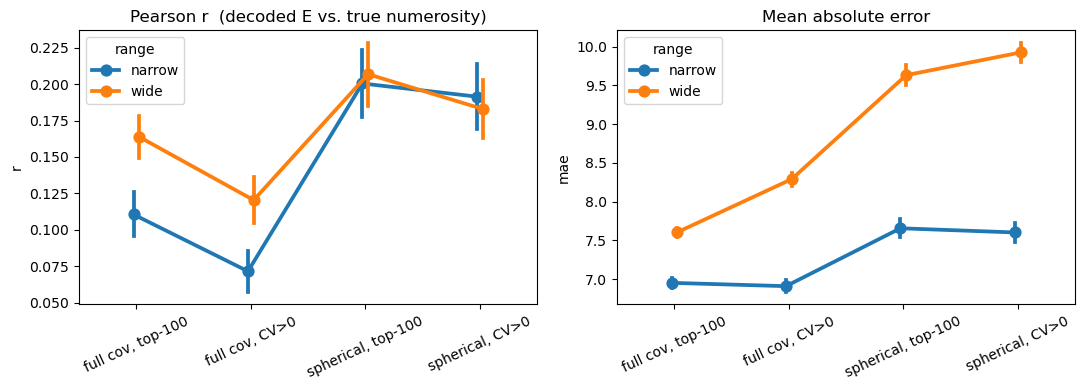

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

order = [c['label'] for c in variant_configs]

sns.pointplot(data=variants, x='config', y='r', hue='range',
              order=order, errorbar='se', dodge=True, ax=axes[0])
axes[0].set_title('Pearson r  (decoded E vs. true numerosity)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=25)

sns.pointplot(data=variants, x='config', y='mae', hue='range',
              order=order, errorbar='se', dodge=True, ax=axes[1])
axes[1].set_title('Mean absolute error')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('compare_noise_voxels.png', dpi=150)
plt.show()

In [5]:
# Paired t-test: full vs. spherical covariance (n_voxels=100, narrow+wide average)
for nv in [100, 0]:
    for rng in ['narrow', 'wide']:
        sub = variants[(variants['n_voxels'] == nv) & (variants['range'] == rng)]
        full_r = sub[sub['noise'] == 'full'].set_index('subject')['r']
        sph_r  = sub[sub['noise'] == 'spherical'].set_index('subject')['r']
        common = full_r.index.intersection(sph_r.index)
        t = pg.ttest(full_r[common], sph_r[common], paired=True)
        print(f'n_voxels={nv}, {rng}: full r={full_r[common].mean():.3f}, '
              f'sph r={sph_r[common].mean():.3f}, '
              f'T={t["T"].values[0]:.2f}, p={t["p-val"].values[0]:.4f}')

n_voxels=100, narrow: full r=0.111, sph r=0.200, T=-5.30, p=0.0000
n_voxels=100, wide: full r=0.164, sph r=0.207, T=-2.50, p=0.0170
n_voxels=0, narrow: full r=0.072, sph r=0.191, T=-5.38, p=0.0000
n_voxels=0, wide: full r=0.120, sph r=0.183, T=-3.42, p=0.0015


In [6]:
# Paired t-test: top-100 vs. CV>0 voxels (full covariance)
for noise in ['full', 'spherical']:
    for rng in ['narrow', 'wide']:
        sub = variants[(variants['noise'] == noise) & (variants['range'] == rng)]
        v100 = sub[sub['n_voxels'] == 100].set_index('subject')['r']
        v0   = sub[sub['n_voxels'] == 0].set_index('subject')['r']
        common = v100.index.intersection(v0.index)
        t = pg.ttest(v100[common], v0[common], paired=True)
        print(f'noise={noise}, {rng}: top-100 r={v100[common].mean():.3f}, '
              f'CV>0 r={v0[common].mean():.3f}, '
              f'T={t["T"].values[0]:.2f}, p={t["p-val"].values[0]:.4f}')

noise=full, narrow: top-100 r=0.111, CV>0 r=0.072, T=2.70, p=0.0103
noise=full, wide: top-100 r=0.164, CV>0 r=0.120, T=2.97, p=0.0051
noise=spherical, narrow: top-100 r=0.200, CV>0 r=0.191, T=1.63, p=0.1121
noise=spherical, wide: top-100 r=0.207, CV>0 r=0.183, T=3.38, p=0.0017


## Part 2: Lambda sweep (empirical covariance blending)

All lambda variants: `fit_responses=True`, `n_voxels=200`, `model31.smoothed`.  
Lambda=0 → fully parametric noise; lambda=1 → fully empirical sample covariance.

**Two confounds separate the lambda sweep from Part 1:**
1. **Target**: `fit_responses=True` → decoding behavioral *response*, not true numerosity. Responses correlate better with neural activity almost by construction (the brain computes a posterior, the response reflects it).
2. **Voxel count**: 200 vs. 100/CV.

To disentangle them we also load `model31.smoothed.fit_responses` at `n_voxels=100` as a **lambda=0 baseline** — same target and parametric noise as the sweep, only fewer voxels. Any further gain from the sweep is attributable to lambda and/or the extra 100 voxels.

In [7]:
lambda_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

lambda_dfs = []

# lambda=0 baseline: same target (fit_responses) and parametric noise, but n_voxels=100
baseline_key = build_key(fit_responses=True)
df_baseline  = collect_metrics(baseline_key, n_voxels=100)
if df_baseline is not None:
    df_baseline['lambda'] = 0.0
    lambda_dfs.append(df_baseline)

for lam in tqdm(lambda_values):
    key = build_key(fit_responses=True, lambd=lam)
    df  = collect_metrics(key, n_voxels=200)
    if df is not None:
        df['lambda'] = lam
        lambda_dfs.append(df)

lambdas = pd.concat(lambda_dfs, ignore_index=True)
print(lambdas.groupby(['lambda', 'range'])[['r', 'mae']].mean().round(3))

  0%|          | 0/10 [00:00<?, ?it/s]

                   r    mae
lambda range               
0.0    narrow  0.135  6.308
       wide    0.174  6.380
0.1    narrow  0.169  4.060
       wide    0.249  6.621
0.2    narrow  0.169  4.059
       wide    0.249  6.620
0.3    narrow  0.169  4.059
       wide    0.249  6.619
0.4    narrow  0.170  4.059
       wide    0.250  6.619
0.5    narrow  0.170  4.059
       wide    0.250  6.621
0.6    narrow  0.170  4.060
       wide    0.250  6.623
0.7    narrow  0.171  4.064
       wide    0.251  6.633
0.8    narrow  0.171  4.077
       wide    0.251  6.657
0.9    narrow  0.170  4.112
       wide    0.249  6.717
1.0    narrow  0.164  4.169
       wide    0.243  6.795


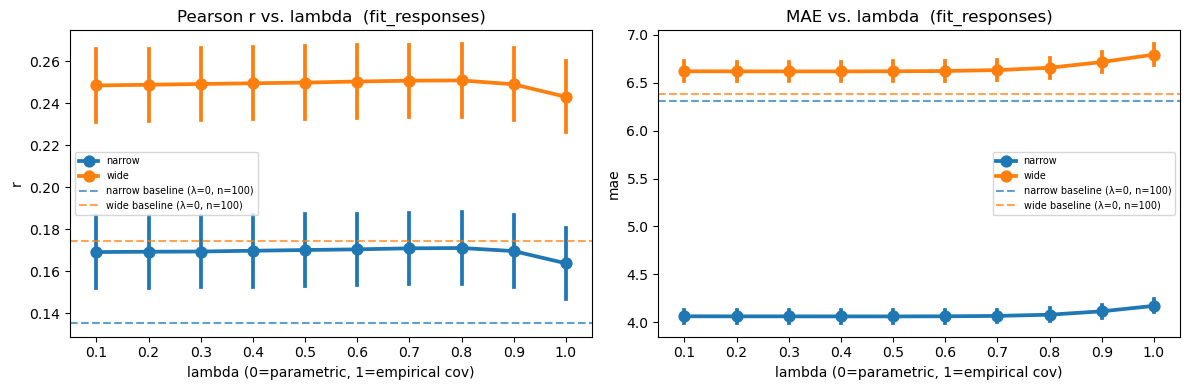

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Separate baseline (lambda=0, n=100) from sweep (lambda>0, n=200) for annotation
sweep = lambdas[lambdas['lambda'] > 0]
base  = lambdas[lambdas['lambda'] == 0.0]

for ax, metric, title in zip(axes,
                              ['r', 'mae'],
                              ['Pearson r vs. lambda  (fit_responses)',
                               'MAE vs. lambda  (fit_responses)']):
    sns.pointplot(data=sweep, x='lambda', y=metric, hue='range',
                  errorbar='se', ax=ax)

    # Draw baseline as horizontal dashed lines (one per range condition)
    for rng, color in zip(['narrow', 'wide'], sns.color_palette()[:2]):
        bval = base[base['range'] == rng][metric].mean()
        ax.axhline(bval, color=color, linestyle='--', alpha=0.7,
                   label=f'{rng} baseline (λ=0, n=100)')

    ax.set_title(title)
    ax.set_xlabel('lambda (0=parametric, 1=empirical cov)')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('compare_lambda.png', dpi=150)
plt.show()

In [9]:
# Mean r per lambda, averaged over range conditions
mean_r = (lambdas.groupby(['lambda', 'range'])['r']
          .mean().unstack('range'))
mean_r['mean'] = mean_r.mean(axis=1)
best_lambda = mean_r['mean'].idxmax()
print(mean_r.round(4))
print(f'\nBest lambda (by average r): {best_lambda}')

range   narrow    wide    mean
lambda                        
0.0     0.1354  0.1742  0.1548
0.1     0.1691  0.2485  0.2088
0.2     0.1693  0.2488  0.2091
0.3     0.1694  0.2492  0.2093
0.4     0.1698  0.2496  0.2097
0.5     0.1701  0.2499  0.2100
0.6     0.1704  0.2504  0.2104
0.7     0.1709  0.2508  0.2108
0.8     0.1711  0.2509  0.2110
0.9     0.1696  0.2490  0.2093
1.0     0.1638  0.2431  0.2034

Best lambda (by average r): 0.8


Distribution of best lambda across subjects:
lambda
0.0     9
0.1     2
0.2     1
0.3     1
0.4     1
0.5     2
0.6     1
0.7     7
0.8    10
0.9     4
1.0     1
Name: count, dtype: int64


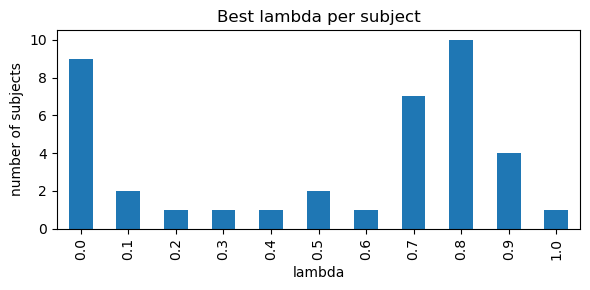

In [10]:
# Per-subject: which lambda maximises r (narrow + wide average)?
best_per_subject = (
    lambdas.groupby(['subject', 'lambda'])['r'].mean()
    .reset_index()
    .sort_values('r', ascending=False)
    .groupby('subject').first()['lambda']
)
print('Distribution of best lambda across subjects:')
print(best_per_subject.value_counts().sort_index())

fig, ax = plt.subplots(figsize=(6, 3))
best_per_subject.value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_xlabel('lambda')
ax.set_ylabel('number of subjects')
ax.set_title('Best lambda per subject')
plt.tight_layout()
plt.show()

## Summary table

In [11]:
# Collect all configurations into one summary table
summary_rows = []

# -- Part 1 variants --
for cfg in variant_configs:
    sub = variants[variants['config'] == cfg['label']]
    for rng, g in sub.groupby('range'):
        summary_rows.append({
            'group': 'noise/voxels',
            'config': cfg['label'],
            'range': rng,
            'n_subjects': g['subject'].nunique(),
            'mean_r': g['r'].mean(),
            'sem_r': g['r'].sem(),
            'mean_mae': g['mae'].mean(),
            'sem_mae': g['mae'].sem(),
        })

# -- Part 2 lambda sweep --
for lam, g in lambdas.groupby('lambda'):
    for rng, gg in g.groupby('range'):
        summary_rows.append({
            'group': 'lambda',
            'config': f'lambda={lam}',
            'range': rng,
            'n_subjects': gg['subject'].nunique(),
            'mean_r': gg['r'].mean(),
            'sem_r': gg['r'].sem(),
            'mean_mae': gg['mae'].mean(),
            'sem_mae': gg['mae'].sem(),
        })

summary = pd.DataFrame(summary_rows)
summary[['mean_r', 'sem_r', 'mean_mae', 'sem_mae']] = summary[['mean_r', 'sem_r', 'mean_mae', 'sem_mae']].round(4)

print('=== Noise/voxel variants ===')
display(summary[summary['group']=='noise/voxels'].drop(columns='group').set_index(['config','range']))

print('\n=== Lambda sweep ===')
display(summary[summary['group']=='lambda'].drop(columns='group').set_index(['config','range']))

=== Noise/voxel variants ===


n_subjects  mean_r   sem_r  mean_mae  sem_mae
config             range                                                
full cov, top-100  narrow          39  0.1105  0.0151    6.9510   0.0654
                   wide            39  0.1638  0.0145    7.6045   0.0552
full cov, CV>0     narrow          39  0.0715  0.0141    6.9082   0.0732
                   wide            39  0.1204  0.0158    8.2902   0.0840
spherical, top-100 narrow          39  0.2004  0.0227    7.6556   0.1179
                   wide            39  0.2068  0.0216    9.6322   0.1331
spherical, CV>0    narrow          39  0.1914  0.0221    7.6016   0.1270
                   wide            39  0.1830  0.0199    9.9259   0.1245


=== Lambda sweep ===


n_subjects  mean_r   sem_r  mean_mae  sem_mae
config     range                                                
lambda=0.0 narrow          39  0.1354  0.0143    6.3076   0.1286
           wide            39  0.1742  0.0170    6.3798   0.1090
lambda=0.1 narrow          39  0.1691  0.0171    4.0602   0.0667
           wide            39  0.2485  0.0172    6.6206   0.1026
lambda=0.2 narrow          39  0.1693  0.0171    4.0595   0.0668
           wide            39  0.2488  0.0172    6.6198   0.1026
lambda=0.3 narrow          39  0.1694  0.0171    4.0594   0.0667
           wide            39  0.2492  0.0172    6.6191   0.1026
lambda=0.4 narrow          39  0.1698  0.0171    4.0590   0.0667
           wide            39  0.2496  0.0172    6.6194   0.1027
lambda=0.5 narrow          39  0.1701  0.0171    4.0588   0.0667
           wide            39  0.2499  0.0172    6.6207   0.1028
lambda=0.6 narrow          39  0.1704  0.0171    4.0601   0.0667
           wide            39  0.2504  0.0172    6.6234   0.1030
lambda=0.7 narrow          39  0.1709  0.0171    4.0639   0.0667
           wide            39  0.2508  0.0172    6.6329   0.1033
lambda=0.8 narrow          39  0.1711  0.0171    4.0768   0.0669
           wide            39  0.2509  0.0172    6.6573   0.1039
lambda=0.9 narrow          39  0.1696  0.0171    4.1121   0.0677
           wide            39  0.2490  0.0171    6.7171   0.1060
lambda=1.0 narrow          39  0.1638  0.0170    4.1690   0.0686
           wide            39  0.2431  0.0169    6.7948   0.1081